In [4]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image

In [5]:
# 1. Configuration des chemins
ROOT_DIR = r'C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData'
train_dir = os.path.join(ROOT_DIR, 'train')
val_dir = os.path.join(ROOT_DIR, 'val')
test_dir = os.path.join(ROOT_DIR, 'test')

In [6]:
# 2. Définition des transformations (L'équivalent de ImageDataGenerator)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    # Les autres augmentations PyTorch s'ajoutent ici
    transforms.ToTensor() # Convertit en tenseur et met les pixels entre 0 et 1
])

In [7]:
# 3. Chargement des données (L'équivalent de flow_from_directory)
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

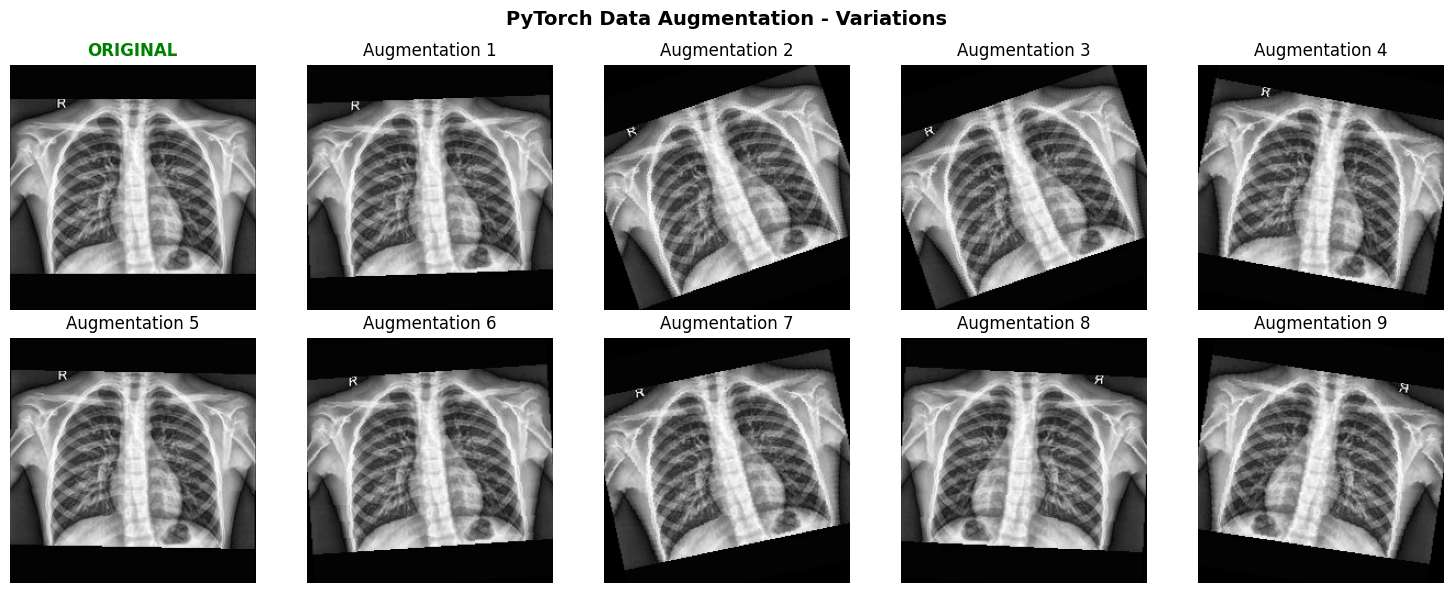

In [ ]:
#  4. Visualisation des augmentations 
#  On cherche une image réelle dans le dataset
first_class_folder = os.path.join(train_dir, os.listdir(train_dir)[0])
img_name = os.listdir(first_class_folder)[0]
img_path = os.path.join(first_class_folder, img_name)

# Chargement en tant qu'objet PIL
pil_img = Image.open(img_path).convert('RGB')

# Configuration de l'affichage
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Image originale (sans augmentation)
axes[0].imshow(transforms.Resize((224, 224))(pil_img))
axes[0].set_title('ORIGINAL', fontweight='bold', color='green')
axes[0].axis('off')

# On génère 9 variations en appliquant le pipeline 'train_transforms' 9 fois
for i in range(1, 10):
    # On applique les transformations
    aug_tensor = train_transforms(pil_img)
    
    # PyTorch renvoie des tenseurs (C, H, W), il faut permuter en (H, W, C) pour matplotlib
    aug_img = aug_tensor.permute(1, 2, 0)
    
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentation {i}')
    axes[i].axis('off')

plt.suptitle('PyTorch Data Augmentation - Variations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()